# Locally Weighted Linear Regression

## Learning Objectives
- Understand why global linear regression fails for non-linear data and how LWLR addresses it
- Understand that LWLR is **non-parametric** and **lazy** — no training phase; all computation happens at prediction time
- Derive the weighted normal equation $\boldsymbol{\theta}^*(x^*) = (X^\top W X)^{-1} X^\top W \mathbf{y}$ from first principles
- Understand the Gaussian kernel and how bandwidth $\tau$ controls the bias–variance tradeoff
- Implement `predict_lwlr` and `predict_lwlr_batch` in NumPy

## Problem Statement

Given a training set $\{(x^{(i)}, y^{(i)})\}_{i=1}^{m}$, predict $\hat{y}^*$ at a **query point** $x^*$ by fitting a linear model that weights training examples by their proximity to $x^*$.

---

### Why Not Global Linear Regression?

Global linear regression fits a single $\boldsymbol{\theta}$ to all $m$ examples and minimizes:

$\displaystyle J(\boldsymbol{\theta}) = \frac{1}{2m}\sum_{i=1}^{m}\bigl(\hat{y}^{(i)} - y^{(i)}\bigr)^2$

When the true relationship is non-linear, a single line underfits everywhere.

---

### Core Idea

Fit a **different** local linear model at every query point $x^*$, weighting nearby training examples more heavily:

$\displaystyle J(\boldsymbol{\theta}; x^*) = \sum_{i=1}^{m} w_i(x^*)\,\bigl(\hat{y}^{(i)} - y^{(i)}\bigr)^2$

where the **Gaussian kernel** weight decays with distance from $x^*$:

$\displaystyle w_i(x^*) = \exp\!\left(-\frac{\|x^{(i)} - x^*\|^2}{2\tau^2}\right)$

| Property | Linear Regression | LWLR |
|---|---|---|
| Model | One global $\boldsymbol{\theta}$ | A new $\boldsymbol{\theta}^*(x^*)$ per query |
| Handles non-linearity | No | Yes (locally linear) |
| Training | $O(n^3)$ once | None (lazy learner) |
| Prediction cost | $O(n)$ | $O(mn^2)$ per query |
| Stores training data | No | Yes (memory-based) |
| Bandwidth $\tau$ | — | Controls bias–variance tradeoff |

---

### Bandwidth $\tau$ and Bias–Variance Tradeoff

$\displaystyle \tau \text{ small} \Rightarrow \text{narrow kernel, high variance (overfit)} \qquad \tau \text{ large} \Rightarrow \text{wide kernel, high bias (underfit)}$

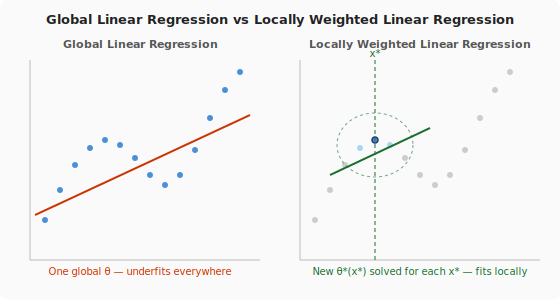

In [1]:
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="560" height="300" viewBox="0 0 560 300">
  <rect width="560" height="300" fill="#fafafa" rx="8"/>

  <text x="280" y="24" text-anchor="middle" font-size="13" font-weight="bold" fill="#222">Global Linear Regression vs Locally Weighted Linear Regression</text>

  <!-- LEFT PANEL: Global fit -->
  <text x="140" y="48" text-anchor="middle" font-size="11" font-weight="bold" fill="#555">Global Linear Regression</text>
  <line x1="30" y1="260" x2="260" y2="260" stroke="#bbb" stroke-width="1"/>
  <line x1="30" y1="60"  x2="30"  y2="260" stroke="#bbb" stroke-width="1"/>

  <!-- Data points (sine-like curve) -->
  <circle cx="45"  cy="220" r="3" fill="#4a90d9"/>
  <circle cx="60"  cy="190" r="3" fill="#4a90d9"/>
  <circle cx="75"  cy="165" r="3" fill="#4a90d9"/>
  <circle cx="90"  cy="148" r="3" fill="#4a90d9"/>
  <circle cx="105" cy="140" r="3" fill="#4a90d9"/>
  <circle cx="120" cy="145" r="3" fill="#4a90d9"/>
  <circle cx="135" cy="158" r="3" fill="#4a90d9"/>
  <circle cx="150" cy="175" r="3" fill="#4a90d9"/>
  <circle cx="165" cy="185" r="3" fill="#4a90d9"/>
  <circle cx="180" cy="175" r="3" fill="#4a90d9"/>
  <circle cx="195" cy="150" r="3" fill="#4a90d9"/>
  <circle cx="210" cy="118" r="3" fill="#4a90d9"/>
  <circle cx="225" cy="90"  r="3" fill="#4a90d9"/>
  <circle cx="240" cy="72"  r="3" fill="#4a90d9"/>

  <!-- Global fit line (bad: straight through curved data) -->
  <line x1="35" y1="215" x2="250" y2="115" stroke="#cc3300" stroke-width="2"/>
  <text x="140" y="275" text-anchor="middle" font-size="10" fill="#cc3300">One global &#x03B8; — underfits everywhere</text>

  <!-- RIGHT PANEL: Local fit -->
  <text x="420" y="48" text-anchor="middle" font-size="11" font-weight="bold" fill="#555">Locally Weighted Linear Regression</text>
  <line x1="300" y1="260" x2="540" y2="260" stroke="#bbb" stroke-width="1"/>
  <line x1="300" y1="60"  x2="300" y2="260" stroke="#bbb" stroke-width="1"/>

  <!-- Same data points -->
  <circle cx="315" cy="220" r="3" fill="#ccc"/>
  <circle cx="330" cy="190" r="3" fill="#ccc"/>
  <circle cx="345" cy="165" r="3" fill="#ccc"/>
  <circle cx="360" cy="148" r="3" fill="#aad4f5"/>
  <circle cx="375" cy="140" r="3" fill="#4a90d9" stroke="#1a3a6e" stroke-width="1.5"/>
  <circle cx="390" cy="145" r="3" fill="#aad4f5"/>
  <circle cx="405" cy="158" r="3" fill="#ccc"/>
  <circle cx="420" cy="175" r="3" fill="#ccc"/>
  <circle cx="435" cy="185" r="3" fill="#ccc"/>
  <circle cx="450" cy="175" r="3" fill="#ccc"/>
  <circle cx="465" cy="150" r="3" fill="#ccc"/>
  <circle cx="480" cy="118" r="3" fill="#ccc"/>
  <circle cx="495" cy="90"  r="3" fill="#ccc"/>
  <circle cx="510" cy="72"  r="3" fill="#ccc"/>

  <!-- Query point marker -->
  <line x1="375" y1="60" x2="375" y2="260" stroke="#1a6e2e" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="375" y="57" text-anchor="middle" font-size="10" fill="#1a6e2e">x*</text>

  <!-- Local fit line (good: fits nearby points well) -->
  <line x1="330" y1="175" x2="430" y2="128" stroke="#1a6e2e" stroke-width="2"/>

  <!-- Kernel weight ellipse (soft highlight around query) -->
  <ellipse cx="375" cy="145" rx="38" ry="32" fill="none" stroke="#1a6e2e" stroke-width="1" stroke-dasharray="3,3" opacity="0.6"/>

  <text x="420" y="275" text-anchor="middle" font-size="10" fill="#1a6e2e">New &#x03B8;*(x*) solved for each x* — fits locally</text>
</svg>
"""

display(SVG(svg))

## Hypothesis Function

For a query point $x^* \in \mathbb{R}^{n+1}$ (with $x_0^* = 1$ prepended), LWLR solves a **new** weighted least squares problem and returns:

$\displaystyle \hat{y}^* = h_{\boldsymbol{\theta}^*}(x^*) = (x^*)^\top \boldsymbol{\theta}^*(x^*)$

where $\boldsymbol{\theta}^*(x^*)$ is the solution to the **weighted normal equation**:

$\displaystyle \boldsymbol{\theta}^*(x^*) = (X^\top W X)^{-1} X^\top W \mathbf{y}$

and $W \in \mathbb{R}^{m \times m}$ is the **diagonal weight matrix** with entries:

$\displaystyle W_{ii} = w_i(x^*) = \exp\!\left(-\frac{\|x^{(i)} - x^*\|^2}{2\tau^2}\right)$

The bandwidth $\tau > 0$ controls how quickly weights decay with distance.

**Key difference from the Normal Equation**: $W$ changes for every query point $x^*$, so $\boldsymbol{\theta}^*$ must be recomputed for each prediction.

## Derivation

**High-level steps:**
1. Define the weighted cost $J(\boldsymbol{\theta}; x^*)$
2. Write in matrix form using the weight matrix $W$
3. Compute the gradient $\nabla_{\boldsymbol{\theta}} J$
4. Set $\nabla_{\boldsymbol{\theta}} J = \mathbf{0}$ and solve for $\boldsymbol{\theta}^*$

---

**Step 1 — Weighted cost**

Weight each example by its proximity to the query point $x^*$:

$\displaystyle J(\boldsymbol{\theta}; x^*) = \sum_{i=1}^{m} w_i\,\bigl(\hat{y}^{(i)} - y^{(i)}\bigr)^2$

where $w_i = \exp\!\left(-\dfrac{\|x^{(i)} - x^*\|^2}{2\tau^2}\right)$.

---

**Step 2 — Matrix form**

Let $W = \mathrm{diag}(w_1, \ldots, w_m) \in \mathbb{R}^{m \times m}$. Then:

$\displaystyle J(\boldsymbol{\theta}; x^*) = (X\boldsymbol{\theta} - \mathbf{y})^\top W (X\boldsymbol{\theta} - \mathbf{y})$

---

**Step 3 — Gradient**

Expanding and differentiating (same matrix calculus identities as the Normal Equation, with $W$ inserted):

$\displaystyle \nabla_{\boldsymbol{\theta}} J = 2 X^\top W (X\boldsymbol{\theta} - \mathbf{y})$

---

**Step 4 — Set gradient to zero and solve**

$\displaystyle X^\top W X\,\boldsymbol{\theta} = X^\top W \mathbf{y}$

$\displaystyle \boxed{\boldsymbol{\theta}^*(x^*) = (X^\top W X)^{-1} X^\top W \mathbf{y}}$

This is the **Weighted Normal Equation**. It reduces to the standard Normal Equation when $W = I$ (uniform weights, $\tau \to \infty$).

## Prediction Algorithm

LWLR is a **lazy learner** — there is no offline training step. All computation happens at prediction time for each query point $x^*$.

**Step 1 — Prepare the design matrix**
Prepend a column of ones to $X$, giving $X \in \mathbb{R}^{m \times (n+1)}$. Also prepend $x_0^* = 1$ to $x^*$.

**Step 2 — Compute kernel weights**
For each training example $x^{(i)}$:

$\displaystyle w_i = \exp\!\left(-\frac{\|x^{(i)} - x^*\|^2}{2\tau^2}\right) \in (0, 1]$

**Step 3 — Form the weight matrix**

$\displaystyle W = \mathrm{diag}(w_1, w_2, \ldots, w_m) \in \mathbb{R}^{m \times m}$

**Step 4 — Solve the weighted normal equation**

$\displaystyle \boldsymbol{\theta}^* = (X^\top W X)^{-1} X^\top W \mathbf{y}$

Use `np.linalg.solve` for numerical stability.

**Step 5 — Predict**

$\displaystyle \hat{y}^* = (x^*)^\top \boldsymbol{\theta}^*$

**Complexity**: $O(mn^2)$ per query point — the dominant cost is forming and solving the $n \times n$ weighted system. For $p$ query points the total cost is $O(pmn^2)$.

## Key Properties

**Non-parametric** — LWLR does not learn a fixed set of parameters. The effective model complexity grows with the data.

**Memory-based (lazy learning)** — all training examples must be stored and used at every prediction. No compression into a parameter vector.

**Gaussian kernel** — the most common weight function. Weights are always positive and sum does not need to equal 1:

$\displaystyle w_i = \exp\!\left(-\frac{\|x^{(i)} - x^*\|^2}{2\tau^2}\right)$

**Bandwidth $\tau$** — the single hyperparameter controlling the tradeoff:

$\displaystyle \tau \to 0 \;\Rightarrow\; \text{only the nearest point matters (high variance)}$

$\displaystyle \tau \to \infty \;\Rightarrow\; W \approx I \;\Rightarrow\; \text{recovers global linear regression (high bias)}$

Optimal $\tau$ is typically chosen by cross-validation.

**Relation to Normal Equation** — the weighted normal equation $(X^\top W X)^{-1} X^\top W \mathbf{y}$ generalizes the standard Normal Equation $(X^\top X)^{-1} X^\top \mathbf{y}$ by inserting $W$ between every $X^\top$ and $X$ (or $\mathbf{y}$).

In [2]:
import numpy as np

def predict_lwlr(X, y, x_query, tau=1.0):
    """
    Inputs
    ------
    X       : np.ndarray, shape (m, n+1)  — design matrix with bias column (x_0 = 1) prepended
    y       : np.ndarray, shape (m,)      — target values
    x_query : np.ndarray, shape (n+1,)    — single query point with bias term (x_0 = 1) prepended
    tau     : float                       — bandwidth; controls how quickly weights decay with distance

    Output
    ------
    y_hat : float  — predicted value at x_query
    """
    diffs = X - x_query                            # (m, n+1)
    distances_sq = np.sum(diffs ** 2, axis=1)      # (m,)
    w = np.exp(-distances_sq / (2 * tau ** 2))     # (m,) Gaussian kernel weights
    W = np.diag(w)                                 # (m, m) diagonal weight matrix
    theta = np.linalg.solve(X.T @ W @ X, X.T @ W @ y)
    return x_query @ theta


def predict_lwlr_batch(X, y, X_query, tau=1.0):
    """
    Inputs
    ------
    X       : np.ndarray, shape (m, n+1)  — design matrix with bias column (x_0 = 1) prepended
    y       : np.ndarray, shape (m,)      — target values
    X_query : np.ndarray, shape (p, n+1)  — p query points with bias column prepended
    tau     : float                       — bandwidth parameter

    Output
    ------
    y_hat : np.ndarray, shape (p,)  — predicted value for each query point
    """
    return np.array([predict_lwlr(X, y, xq, tau) for xq in X_query])